In [1]:
import os
import pandas as pd


In [2]:
df = pd.read_csv('./train.csv')

In [3]:
# Print basic information about the dataset
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n" + "="*50)

# Display first few rows
print("First 5 rows:")
print(df.head())
print("\n" + "="*50)

# Display basic info about the dataframe
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)

# Display statistical summary
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*50)

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)

# Display column names and data types
print("Columns and Data Types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

Dataset Shape:
Rows: 59904, Columns: 88

First 5 rows:
   Unnamed: 0                                    id  sex  age  innet_dura  \
0           1  738f9d93-b51b-47c9-97f0-590527042013    1   34          17   
1           2  b0384a6e-0330-4e8f-a13e-b59acfcca5ad    1   37         132   
2           3  90631d89-e5f0-46eb-afd3-ac104f830fa1    1   41          35   
3           4  6dc8992e-5f5f-4f4b-90e6-cd1b00038928    1   34          91   
4           5  3ecaed5b-abd4-4a7e-9620-ee8441adc124    2   27         129   

    arpu  l3m_avg_mou  l3m_avg_dou  l3m_avg_bill_dura  cm_tot_bill_dura  ...  \
0   84.5    1049.0000     412.5410                0.0                 0  ...   
1  172.0     210.6667   25779.4310                0.0                 0  ...   
2  116.0      83.6667   14559.4574                0.0                 0  ...   
3  158.0     128.0000   34731.8750                0.0                 0  ...   
4   99.0      44.0000   29129.3919                0.0                 0  ...   

 

In [4]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

def preprocess_data(df, encoders=None, scaler=None, imputers=None, feature_selector=None, selected_features=None, is_training=True):
    """
    优化版的数据预处理函数 - 修复所有bug，包含所有必要参数
    """
    
    data = df.copy()
    
    # 定义在函数开头，确保在训练和测试时都能访问
    high_missing_features = [
        'gm_use_dur', 'gm_dayt_use_dur', 'gm_ngt_use_dur',
        'shrt_vid_use_dur', 'shrt_vid_dayt_use_dur', 'shrt_vid_ngt_use_dur',
        'long_vid_use_dur', 'long_vid_dayt_use_dur', 'long_vid_ngt_use_dur',
        'anchor_use_dur', 'anchor_dayt_use_dur', 'anchor_ngt_use_dur',
        'wtch_liv_use_dur', 'wtch_liv_dayt_use_dur', 'wtch_liv_ngt_use_dur',
        'netdisk_use_dur', 'netdisk_dayt_use_dur', 'netdisk_ngt_use_dur'
    ]
    
    user_label_features = [
        'hi_flux_usr_lbl', 'sev_vid_usr_lbl', 'liv_usr_lbl',
        'netdisk_usr_lbl', 'vid_usr_lbl', 'read_usr_lbl',
        'gm_usr_lbl', 'msc_usr_lbl'
    ]
    
    # 1. 数据类型转换
    print("Converting data types...")
    numeric_columns = [col for col in data.columns if col not in ['id', 'label', 'sex']]
    for col in numeric_columns:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')
    
    # 性别特殊处理
    if 'sex' in data.columns:
        data['sex'] = data['sex'].replace({'0': 'unknown', '1': 'male', '2': 'female'})
    
    # 2. 异常值检测和处理
    print("Handling outliers...")
    if is_training:
        outlier_thresholds = {}
        numeric_cols_for_outlier = ['arpu', 'l3m_avg_dou', 'cm_flux_use', 'bd_flux_m', 'user_duration_m']
        
        for col in numeric_cols_for_outlier:
            if col in data.columns:
                Q1 = data[col].quantile(0.25)
                Q3 = data[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                outlier_thresholds[col] = (lower_bound, upper_bound)
                
                # 缩尾处理
                data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
                data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])
    else:
        # 使用训练集的阈值处理测试集异常值
        if imputers and 'outlier_thresholds' in imputers:
            outlier_thresholds = imputers['outlier_thresholds']
            for col, (lower_bound, upper_bound) in outlier_thresholds.items():
                if col in data.columns:
                    data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
                    data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])
    
    # 3. 分组特征
    print("Creating grouped features...")
    
    data['age_group'] = pd.cut(data['age'], 
                              bins=[0, 25, 35, 45, 55, 65, 100], 
                              labels=['young', 'young_adult', 'adult', 'middle', 'senior', 'elderly'])
    
    data['tenure_group'] = pd.cut(data['innet_dura'], 
                                 bins=[0, 3, 6, 12, 24, 60, 1000], 
                                 labels=['very_new', 'new', 'short', 'medium', 'long', 'very_long'])
    
    data['arpu_group'] = pd.cut(data['arpu'], 
                               bins=[0, 30, 60, 100, 200, 500, 1000], 
                               labels=['very_low', 'low', 'medium', 'high', 'premium', 'vip'])
    
    # 4. 缺失值处理策略优化
    print("Handling missing values...")
    
    if is_training:
        imputers = {}
        
        # 对高缺失率特征使用KNN插值
        available_high_missing = [col for col in high_missing_features if col in data.columns]
        if available_high_missing:
            knn_imputer = KNNImputer(n_neighbors=5)
            data[available_high_missing] = knn_imputer.fit_transform(data[available_high_missing])
            imputers['knn'] = knn_imputer
        
        # 对用户标签特征使用众数插值
        available_labels = [col for col in user_label_features if col in data.columns]
        if available_labels:
            mode_imputer = SimpleImputer(strategy='most_frequent')
            data[available_labels] = mode_imputer.fit_transform(data[available_labels])
            imputers['mode'] = mode_imputer
        
        # 对其他数值特征使用中位数插值
        other_numeric = data.select_dtypes(include=[np.number]).columns
        other_numeric = [col for col in other_numeric if col not in available_high_missing + available_labels + ['label']]
        if other_numeric:
            median_imputer = SimpleImputer(strategy='median')
            data[other_numeric] = median_imputer.fit_transform(data[other_numeric])
            imputers['median'] = median_imputer
            
        # 保存异常值阈值
        imputers['outlier_thresholds'] = outlier_thresholds
            
    else:
        # 测试集使用训练集的插值器
        if imputers and 'knn' in imputers:
            available_high_missing = [col for col in high_missing_features if col in data.columns]
            if available_high_missing:
                data[available_high_missing] = imputers['knn'].transform(data[available_high_missing])
        
        if imputers and 'mode' in imputers:
            available_labels = [col for col in user_label_features if col in data.columns]
            if available_labels:
                data[available_labels] = imputers['mode'].transform(data[available_labels])
        
        if imputers and 'median' in imputers:
            other_numeric = data.select_dtypes(include=[np.number]).columns
            other_numeric = [col for col in other_numeric if col not in available_high_missing + available_labels + ['label']]
            if other_numeric:
                data[other_numeric] = imputers['median'].transform(data[other_numeric])
    
    # 5. 高级特征工程 - 保持原变量名称但优化计算逻辑
    print("Creating engineered features...")
    
    # 使用更稳健的计算方式
    data['total_flux_usage'] = np.where(
        (data['flux_4g_use'].notna()) & (data['cm_flux_use'].notna()),
        data['flux_4g_use'] + data['cm_flux_use'],
        np.nan
    )
    
    data['flux_efficiency'] = np.where(
        (data['total_flux_usage'].notna()) & (data['arpu'].notna()) & (data['arpu'] > 0),
        data['total_flux_usage'] / data['arpu'],
        0
    )
    
    data['voice_data_ratio'] = np.where(
        (data['l3m_avg_mou'].notna()) & (data['l3m_avg_dou'].notna()) & (data['l3m_avg_dou'] > 0),
        data['l3m_avg_mou'] / data['l3m_avg_dou'],
        0
    )
    
    # 时间使用模式 - 添加边界检查
    day_flux = data['wday_day_flux'] + data['nwday_day_flux']
    night_flux = data['wday_night_flux'] + data['nwday_night_flux']
    data['day_night_flux_ratio'] = np.where(
        night_flux > 0, day_flux / night_flux, day_flux
    )
    
    weekday_flux = data['wday_day_flux'] + data['wday_night_flux']
    weekend_flux = data['nwday_day_flux'] + data['nwday_night_flux']
    data['weekday_weekend_ratio'] = np.where(
        weekend_flux > 0, weekday_flux / weekend_flux, weekday_flux
    )
    
    # 套餐使用效率 - 防止除零
    data['base_plan_utilization'] = np.where(
        (data['cm_base_plan_flux'].notna()) & (data['cm_base_plan_flux'] > 0),
        data['cm_base_plan_flux_use'] / data['cm_base_plan_flux'],
        0
    )
    
    data['chosen_plan_utilization'] = np.where(
        (data['cm_chos_plan_flux'].notna()) & (data['cm_chos_plan_flux'] > 0),
        data['cm_chos_plan_flux_use'] / data['cm_chos_plan_flux'],
        0
    )
    
    data['over_plan_ratio'] = np.where(
        (data['total_flux_usage'].notna()) & (data['total_flux_usage'] > 0),
        data['cm_over_plan_flux'] / data['total_flux_usage'],
        0
    )
    
    # 用户活跃度特征
    data['avg_daily_clicks'] = np.where(
        (data['click_times_m'].notna()) & (data['open_day_m'].notna()) & (data['open_day_m'] > 0),
        data['click_times_m'] / data['open_day_m'],
        0
    )
    
    data['avg_session_duration'] = np.where(
        (data['user_duration_m'].notna()) & (data['login_times_m'].notna()) & (data['login_times_m'] > 0),
        data['user_duration_m'] / data['login_times_m'],
        0
    )
    
    data['engagement_score'] = np.where(
        (data['watch_times_m'].notna()) & (data['click_times_m'].notna()) & (data['click_times_m'] > 0),
        data['watch_times_m'] / data['click_times_m'],
        0
    )
    
    # 内容消费模式 - 添加缺失值处理
    content_time_cols = ['read_time_m', 'cajing_time_m', 'travel_time_m', 'edu_time_m', 'fashion_time_m']
    content_count_cols = ['video_cnt_m', 'read_cnt_m', 'music_cnt_m', 'cajing_cnt_m', 'travel_cnt_m', 'game_cnt_m', 'edu_cnt_m']
    
    # 只对存在的列求和
    available_time_cols = [col for col in content_time_cols if col in data.columns]
    available_count_cols = [col for col in content_count_cols if col in data.columns]
    
    data['total_content_time'] = data[available_time_cols].sum(axis=1, skipna=True)
    data['total_content_count'] = data[available_count_cols].sum(axis=1, skipna=True)
    
    # 应用使用模式
    app_duration_cols = ['gm_use_dur', 'shrt_vid_use_dur', 'long_vid_use_dur', 
                        'anchor_use_dur', 'wtch_liv_use_dur', 'netdisk_use_dur']
    available_app_cols = [col for col in app_duration_cols if col in data.columns]
    
    data['total_app_usage'] = data[available_app_cols].sum(axis=1, skipna=True)
    
    data['video_usage_total'] = np.where(
        (data['shrt_vid_use_dur'].notna()) & (data['long_vid_use_dur'].notna()),
        data['shrt_vid_use_dur'] + data['long_vid_use_dur'],
        np.nan
    )
    
    # 日间夜间应用使用比例
    day_app_usage = data['gm_dayt_use_dur'] + data['shrt_vid_dayt_use_dur'] + data['long_vid_dayt_use_dur']
    night_app_usage = data['gm_ngt_use_dur'] + data['shrt_vid_ngt_use_dur'] + data['long_vid_ngt_use_dur']
    data['day_night_app_ratio'] = np.where(
        night_app_usage > 0, day_app_usage / night_app_usage, day_app_usage
    )
    
    # 客户价值分段 - 使用更稳健的分段逻辑
    if is_training:
        arpu_threshold = data['arpu'].quantile(0.8)
        flux_threshold = data['total_flux_usage'].quantile(0.8)
    else:
        # 使用合理的默认值
        arpu_threshold = 150
        flux_threshold = 50000
    
    data['high_value_customer'] = ((data['arpu'] > arpu_threshold) & 
                                  (data['innet_dura'] > 12)).astype(int)
    
    data['heavy_data_user'] = (data['total_flux_usage'] > flux_threshold).astype(int)
    
    # 多服务用户判断
    service_cols = ['is_fam_vnet_user', 'is_ent_vnet_user', 'is_bd_tv', 'if_nulim_prod']
    available_service_cols = [col for col in service_cols if col in data.columns]
    data['multi_service_user'] = (data[available_service_cols].sum(axis=1) >= 2).astype(int)
    
    # 6. 编码分类特征
    print("Encoding categorical features...")
    categorical_features = ['age_group', 'tenure_group', 'arpu_group']
    
    if is_training:
        encoders = {}
        for feature in categorical_features:
            le = LabelEncoder()
            data[f'{feature}_encoded'] = le.fit_transform(data[feature].astype(str))
            encoders[feature] = le
    else:
        for feature in categorical_features:
            # 处理未见过的类别
            if encoders and feature in encoders:
                known_classes = set(encoders[feature].classes_)
                data[feature] = data[feature].astype(str)
                data[feature] = data[feature].apply(lambda x: x if x in known_classes else encoders[feature].classes_[0])
                data[f'{feature}_encoded'] = encoders[feature].transform(data[feature])
    
    # 7. 特征选择 - 保持原特征选择逻辑但优化实现
    print("Selecting features...")
    
    # 保持原有的特征分组
    demographic_features = ['sex', 'age', 'innet_dura']
    
    usage_features = [
        'arpu', 'l3m_avg_mou', 'l3m_avg_dou', 'l3m_avg_bill_dura',
        'cm_tot_bill_dura', 'cm_local_voice_dura', 'cm_flux_use',
        'flux_4g_use', 'flux_up_4g_sum', 'flux_down_4g_sum'
    ]
    
    time_usage_features = [
        'wday_day_flux', 'wday_night_flux', 'nwday_day_flux', 'nwday_night_flux'
    ]
    
    plan_features = [
        'cm_flux_tot_cnt', 'cm_base_plan_flux', 'cm_base_plan_flux_use',
        'cm_chos_plan_flux', 'cm_chos_plan_flux_use', 'cm_over_plan_flux',
        'gprs_days'
    ]
    
    binary_features = [
        'is_fam_vnet_user', 'is_ent_vnet_user', 'is_bd_status_abnormal',
        'is_10g_pon', 'is_bd_tv', 'if_nulim_prod'
    ]
    
    broadband_features = ['bd_flux_m', 'bd_dur_m', 'bd_cnt_m']
    
    activity_features = [
        'user_duration_m', 'login_times_m', 'click_times_m', 'watch_times_m',
        'open_day_m', 'click_day_m'
    ]
    
    contract_features = ['term_cont_mon', 'term_cont_dfee', 'grp_cnts']
    
    usage_pattern_features = ['out_gprs', 'out_call']
    
    content_features = [
        'video_cnt_m', 'read_time_m', 'read_cnt_m', 'music_cnt_m',
        'cajing_time_m', 'cajing_cnt_m', 'travel_time_m', 'travel_cnt_m',
        'game_cnt_m', 'edu_time_m', 'edu_cnt_m', 'fashion_time_m'
    ]
    
    preference_features = [
        'if_high_games_cust', 'if_like_games_cust', 'if_like_video_cust'
    ]
    
    app_usage_features = [
        'gm_use_dur', 'gm_dayt_use_dur', 'gm_ngt_use_dur',
        'shrt_vid_use_dur', 'shrt_vid_dayt_use_dur', 'shrt_vid_ngt_use_dur',
        'long_vid_use_dur', 'long_vid_dayt_use_dur', 'long_vid_ngt_use_dur',
        'anchor_use_dur', 'anchor_dayt_use_dur', 'anchor_ngt_use_dur',
        'wtch_liv_use_dur', 'wtch_liv_dayt_use_dur', 'wtch_liv_ngt_use_dur',
        'netdisk_use_dur', 'netdisk_dayt_use_dur', 'netdisk_ngt_use_dur'
    ]
    
    user_label_features = [
        'hi_flux_usr_lbl', 'sev_vid_usr_lbl', 'liv_usr_lbl',
        'netdisk_usr_lbl', 'vid_usr_lbl', 'read_usr_lbl',
        'gm_usr_lbl', 'msc_usr_lbl'
    ]
    
    # 工程特征 - 保持原名称
    engineered_features = [
        'total_flux_usage', 'flux_efficiency', 'voice_data_ratio',
        'day_night_flux_ratio', 'weekday_weekend_ratio',
        'base_plan_utilization', 'chosen_plan_utilization', 'over_plan_ratio',
        'avg_daily_clicks', 'avg_session_duration', 'engagement_score',
        'total_content_time', 'total_content_count',
        'total_app_usage', 'video_usage_total', 'day_night_app_ratio',
        'high_value_customer', 'heavy_data_user', 'multi_service_user',
        'age_group_encoded', 'tenure_group_encoded', 'arpu_group_encoded'
    ]
    
    # 合并基础特征
    base_features = (demographic_features + usage_features + time_usage_features + 
                    plan_features + binary_features + broadband_features + 
                    activity_features + contract_features + usage_pattern_features + 
                    content_features + preference_features + app_usage_features + 
                    user_label_features)
    
    # 只选择实际存在的特征
    available_base_features = [f for f in base_features if f in data.columns]
    available_engineered_features = [f for f in engineered_features if f in data.columns]
    
    feature_columns = available_base_features + available_engineered_features
    
    # 创建特征矩阵
    X = data[feature_columns].copy()
    
    # 处理无穷值和NaN
    X = X.replace([np.inf, -np.inf], np.nan)
    
    if is_training:
        # 填充剩余NaN值
        numeric_columns = X.select_dtypes(include=[np.number]).columns
        X[numeric_columns] = X[numeric_columns].fillna(X[numeric_columns].median())
        
        # 特征选择 - 使用SelectKBest选择最重要的特征
        selector = SelectKBest(score_func=f_classif, k=min(50, len(feature_columns)))
        if 'label' in data.columns:
            X_selected = selector.fit_transform(X, data['label'])
            selected_features = [feature_columns[i] for i in selector.get_support(indices=True)]
            X = X[selected_features]
            feature_columns = selected_features
        else:
            selected_features = feature_columns
        
        print(f"Selected {len(feature_columns)} features")
        
        y = data['label']
        fitted_objects = {
            'encoders': encoders,
            'imputers': imputers,
            'feature_selector': selector,
            'selected_features': feature_columns
        }
        return X, y, feature_columns, fitted_objects
    else:
        # 使用训练集选择的特征
        if selected_features:
            # 确保测试集包含所有训练集特征，缺少的用0填充
            missing_features = set(selected_features) - set(X.columns)
            for feature in missing_features:
                X[feature] = 0
            X = X[selected_features]
            feature_columns = selected_features
        else:
            # 如果没有指定特征，使用所有特征
            feature_columns = feature_columns
        
        # 填充剩余NaN值
        numeric_columns = X.select_dtypes(include=[np.number]).columns
        for col in numeric_columns:
            if col in X.columns:
                X[col] = X[col].fillna(X[col].median())
        
        return X, feature_columns

Converting data types...
Handling outliers...
Creating grouped features...
Handling missing values...
Creating engineered features...
Encoding categorical features...
Selecting features...
Selected 50 features
Training set size: (47923, 50)
Test set size: (11981, 50)
Target distribution in training set:
label
0    0.749598
1    0.250402
Name: proportion, dtype: float64

Training Random Forest
Accuracy: 0.8025
ROC AUC: 0.8354
Cross-validation ROC AUC: 0.8343 (+/- 0.0019)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      8981
           1       0.66      0.43      0.52      3000

    accuracy                           0.80     11981
   macro avg       0.75      0.68      0.70     11981
weighted avg       0.79      0.80      0.79     11981


Confusion Matrix:
[[8324  657]
 [1709 1291]]

Training Logistic Regression
Accuracy: 0.7682
ROC AUC: 0.7741
Cross-validation ROC AUC: 0.7854 (+/- 0.0052)

Classification Rep

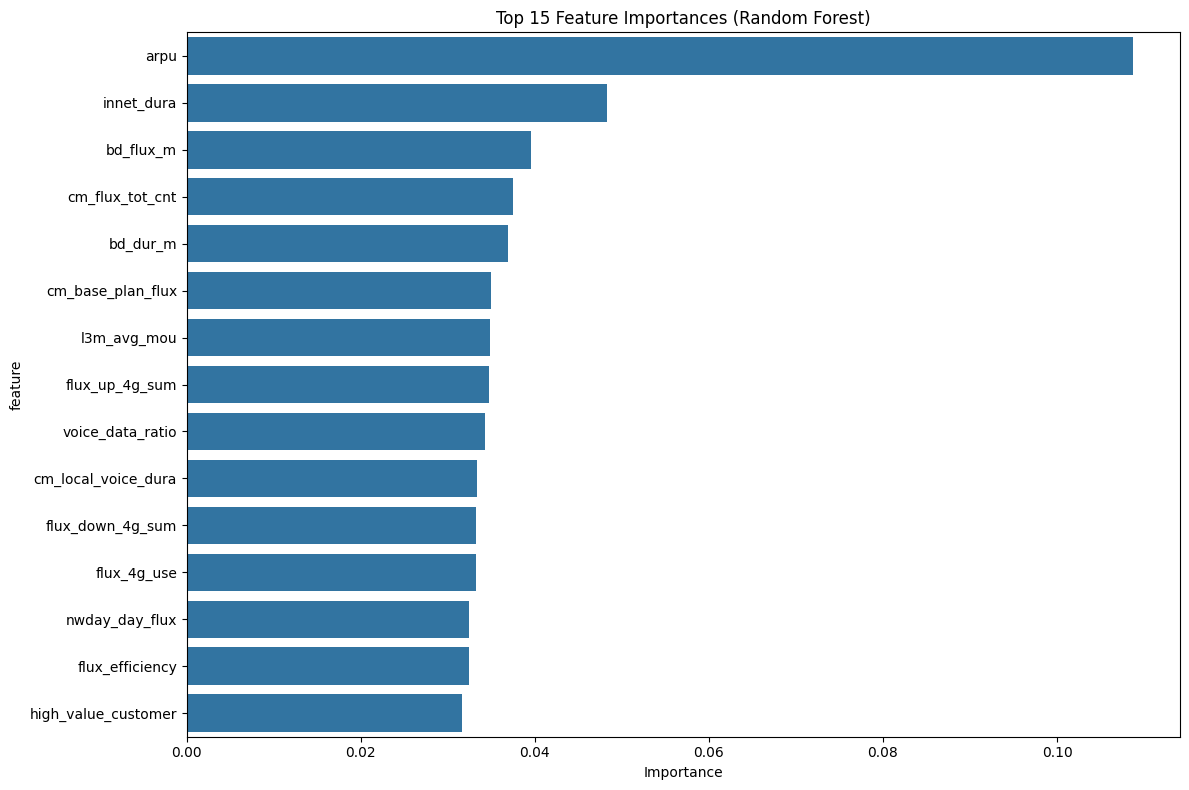


Model Comparison
                 Model  Test Accuracy  Test ROC AUC  CV ROC AUC (mean)  \
0        Random Forest       0.802521      0.835352           0.834285   
1  Logistic Regression       0.768216      0.774087           0.785408   

   CV ROC AUC (std)  
0          0.000931  
1          0.002594  


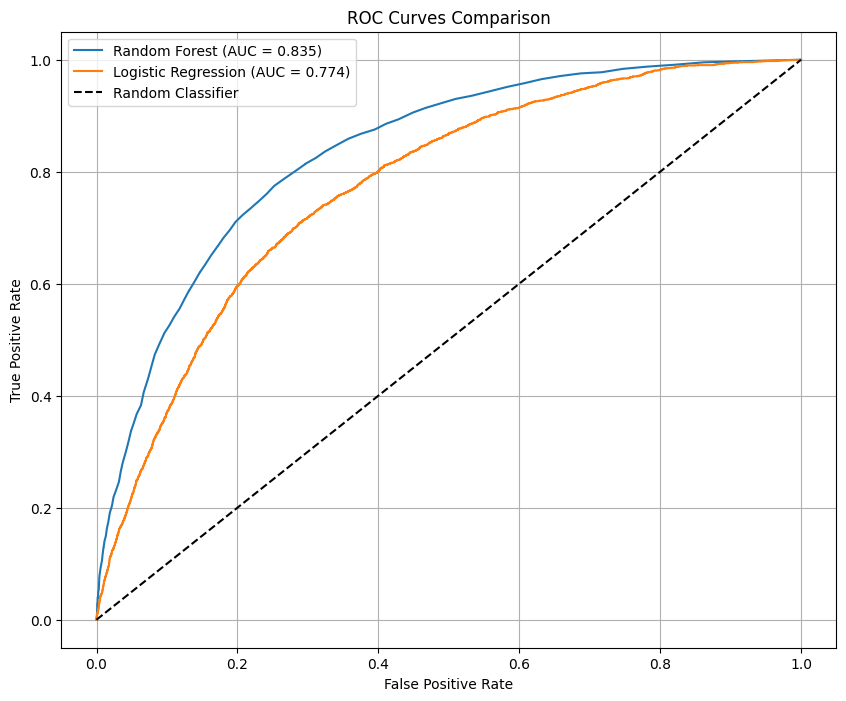


Best model: Random Forest
Best model ROC AUC: 0.8354

Final Model Evaluation: Random Forest
Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.93      0.88      8981
    Positive       0.66      0.43      0.52      3000

    accuracy                           0.80     11981
   macro avg       0.75      0.68      0.70     11981
weighted avg       0.79      0.80      0.79     11981



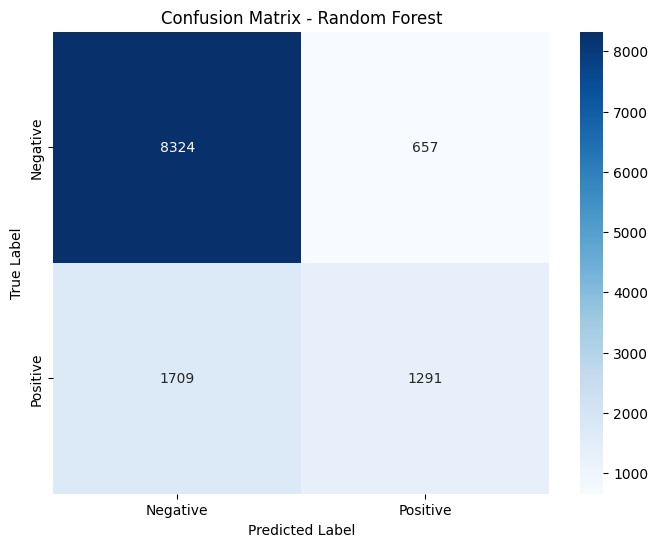


Model saved as: best_classifier_random_forest.pkl
Scaler saved as: feature_scaler.pkl


In [5]:
# # Run analysis
# analyze_dataset(df)

# # Preprocess the data
# print("\nPreprocessing data...")
# X, y, feature_columns, fitted_objects = preprocess_data(df, is_training=True)

# print(f"\nPreprocessing complete!")
# print(f"Features shape: {X.shape}")
# print(f"Target shape: {y.shape}")
# print(f"Target distribution: {y.value_counts(normalize=True).to_dict()}")

# Preprocess the data
X, y, feature_columns, fitted_objects = preprocess_data(df, is_training=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Target distribution in training set:")
print(y_train.value_counts(normalize=True))

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train multiple models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}")
    print('='*50)
    
    # Use scaled data for Logistic Regression, original for Random Forest
    if name == 'Logistic Regression':
        X_train_model = X_train_scaled
        X_test_model = X_test_scaled
    else:
        X_train_model = X_train
        X_test_model = X_test
    
    # Train the model
    model.fit(X_train_model, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_model)
    y_pred_proba = model.predict_proba(X_test_model)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_model, y_train, cv=5, scoring='roc_auc')
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Cross-validation ROC AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

# Feature importance for Random Forest
if 'Random Forest' in results:
    print(f"\n{'='*50}")
    print("Feature Importance (Random Forest)")
    print('='*50)
    
    rf_model = results['Random Forest']['model']
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(feature_importance.head(15))
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
    plt.title('Top 15 Feature Importances (Random Forest)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# Compare models
print(f"\n{'='*50}")
print("Model Comparison")
print('='*50)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'Test ROC AUC': [results[name]['roc_auc'] for name in results.keys()],
    'CV ROC AUC (mean)': [results[name]['cv_mean'] for name in results.keys()],
    'CV ROC AUC (std)': [results[name]['cv_std'] for name in results.keys()]
})

print(comparison_df)

# Plot ROC curves
plt.figure(figsize=(10, 8))
for name in results.keys():
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Select best model based on ROC AUC
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']

print(f"\nBest model: {best_model_name}")
print(f"Best model ROC AUC: {results[best_model_name]['roc_auc']:.4f}")

# Final model evaluation
print(f"\n{'='*50}")
print(f"Final Model Evaluation: {best_model_name}")
print('='*50)

best_y_pred = results[best_model_name]['y_pred']
best_y_pred_proba = results[best_model_name]['y_pred_proba']

print("Detailed Classification Report:")
print(classification_report(y_test, best_y_pred, target_names=['Negative', 'Positive']))

# Confusion matrix heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Save the best model (optional)
import joblib
joblib.dump(best_model, f'best_classifier_{best_model_name.lower().replace(" ", "_")}.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

print(f"\nModel saved as: best_classifier_{best_model_name.lower().replace(' ', '_')}.pkl")
print("Scaler saved as: feature_scaler.pkl")

In [7]:
df_test = pd.read_csv('./testA.csv')

In [8]:
# Print basic information about the dataset
print("Dataset Shape:")
print(f"Rows: {df_test.shape[0]}, Columns: {df_test.shape[1]}")
print("\n" + "="*50)

# Display first few rows
print("First 5 rows:")
print(df_test.head())
print("\n" + "="*50)

# Display basic info about the dataframe
print("Dataset Info:")
print(df_test.info())
print("\n" + "="*50)

# Display statistical summary
print("Statistical Summary:")
print(df_test.describe())
print("\n" + "="*50)

# Check for missing values
print("Missing Values:")
print(df_test.isnull().sum())
print("\n" + "="*50)

# Display column names and data types
print("Columns and Data Types:")
for col in df_test.columns:
    print(f"{col}: {df_test[col].dtype}")

Dataset Shape:
Rows: 19999, Columns: 87

First 5 rows:
   Unnamed: 0                                    id  sex  age  innet_dura  \
0           1  7780c4fd-8b15-450e-9bba-37204c169d35    2   45         212   
1           2  1a9a2021-b3dd-4882-af8c-17456d5a875c    2   21          34   
2           3  ec71eda8-45d7-4c5a-a1b3-33a84054a3eb    1   69         222   
3           4  51e63ed3-bc51-4cb0-b282-1375ed6d9ee1    1   32         120   
4           5  76e9abe7-211d-4f32-832f-236051922d2f    1   78         150   

    arpu  l3m_avg_mou  l3m_avg_dou  l3m_avg_bill_dura  cm_tot_bill_dura  ...  \
0  89.00     162.6667   10269.8337             0.0000                 0  ...   
1  49.00      53.6667   17566.1383             0.0000                 0  ...   
2  37.19      28.3333     343.4710             0.0000                 0  ...   
3  42.58     103.3333    5869.7920            16.6667                22  ...   
4  74.00     140.0000       0.3249             0.0000                 0  ...   

 

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

def analyze_dataset(df):
    """
    Quick analysis of the dataset
    """
    print("Dataset Analysis:")
    print(f"Shape: {df.shape}")
    print(f"\nTarget distribution:")
    print(df['label'].value_counts(normalize=True))
    
    print(f"\nMissing values by column:")
    missing_cols = df.isnull().sum()
    missing_cols = missing_cols[missing_cols > 0].sort_values(ascending=False)
    print(missing_cols.head(10))
    
    print(f"\nBasic statistics for key features:")
    key_features = ['age', 'innet_dura', 'arpu', 'l3m_avg_mou', 'l3m_avg_dou']
    print(df[key_features].describe())

def train_and_predict_pipeline(df_train, df_test):
    """
    Complete pipeline to train models and predict on test set
    """
    print("="*60)
    print("TELECOM CUSTOMER CLASSIFICATION PIPELINE")
    print("="*60)
    
    # Preprocess training data
    print("\n1. Preprocessing training data...")
    X_train, y_train, feature_columns, fitted_objects = preprocess_data(df_train, is_training=True)
    
    print(f"Training data shape: {X_train.shape}")
    print(f"Target distribution in training:")
    print(y_train.value_counts(normalize=True))
    
    # Preprocess test data - 修复这里，传递所有必要的参数
    print("\n2. Preprocessing test data...")
    X_test, _ = preprocess_data(df_test, 
                                encoders=fitted_objects.get('encoders'),
                                imputers=fitted_objects.get('imputers'),
                                selected_features=fitted_objects.get('selected_features'),
                                is_training=False)
    
    print(f"Test data shape: {X_test.shape}")
    
    # Split training data for validation
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )
    
    # Scale features
    print("\n3. Scaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_split)
    X_val_scaled = scaler.transform(X_val_split)
    X_test_scaled = scaler.transform(X_test)
    
    # Define models
    models = {
        'Random Forest': {
            'model': RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            ),
            'use_scaled': False
        },
        'Gradient Boosting': {
            'model': GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=6,
                random_state=42
            ),
            'use_scaled': False
        },
        'Logistic Regression': {
            'model': LogisticRegression(
                random_state=42,
                max_iter=1000,
                C=1.0
            ),
            'use_scaled': True
        }
    }
    
    print("\n4. Training and evaluating models...")
    results = {}
    
    for name, model_config in models.items():
        print(f"\n{'='*40}")
        print(f"Training {name}")
        print('='*40)
        
        model = model_config['model']
        use_scaled = model_config['use_scaled']
        
        # Select appropriate data
        if use_scaled:
            X_train_model = X_train_scaled
            X_val_model = X_val_scaled
            X_test_model = X_test_scaled
        else:
            X_train_model = X_train_split
            X_val_model = X_val_split
            X_test_model = X_test
        
        # Train model
        model.fit(X_train_model, y_train_split)
        
        # Validation predictions
        y_val_pred = model.predict(X_val_model)
        y_val_pred_proba = model.predict_proba(X_val_model)[:, 1]
        
        # Test predictions
        y_test_pred = model.predict(X_test_model)
        y_test_pred_proba = model.predict_proba(X_test_model)[:, 1]
        
        # Calculate metrics
        val_accuracy = accuracy_score(y_val_split, y_val_pred)
        val_roc_auc = roc_auc_score(y_val_split, y_val_pred_proba)
        
        # Cross-validation on full training data
        if use_scaled:
            X_full_scaled = scaler.fit_transform(X_train)
            cv_scores = cross_val_score(model, X_full_scaled, y_train, cv=5, scoring='roc_auc')
        else:
            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
        
        results[name] = {
            'model': model,
            'val_accuracy': val_accuracy,
            'val_roc_auc': val_roc_auc,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'test_predictions': y_test_pred,
            'test_probabilities': y_test_pred_proba,
            'use_scaled': use_scaled
        }
        
        print(f"Validation Accuracy: {val_accuracy:.4f}")
        print(f"Validation ROC AUC: {val_roc_auc:.4f}")
        print(f"CV ROC AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
        
        print("\nValidation Classification Report:")
        print(classification_report(y_val_split, y_val_pred))
    
    # Select best model
    best_model_name = max(results.keys(), key=lambda x: results[x]['cv_mean'])
    best_result = results[best_model_name]
    
    print(f"\n{'='*60}")
    print(f"BEST MODEL: {best_model_name}")
    print(f"Cross-validation ROC AUC: {best_result['cv_mean']:.4f}")
    print("="*60)
    
    # Feature importance for tree-based models
    if best_model_name in ['Random Forest', 'Gradient Boosting']:
        print(f"\nTop 20 Feature Importances ({best_model_name}):")
        feature_importance = pd.DataFrame({
            'feature': feature_columns,
            'importance': best_result['model'].feature_importances_
        }).sort_values('importance', ascending=False)
        
        print(feature_importance.head(20).to_string(index=False))
    
    # Create final predictions
    print(f"\n5. Creating final predictions using {best_model_name}...")
    
    # Retrain on full training data for final predictions
    best_model = models[best_model_name]['model']
    
    if best_result['use_scaled']:
        X_train_final = scaler.fit_transform(X_train)
        X_test_final = scaler.transform(X_test)
    else:
        X_train_final = X_train
        X_test_final = X_test
    
    # Final training
    best_model.fit(X_train_final, y_train)
    
    # Final predictions
    final_predictions = best_model.predict(X_test_final)
    final_probabilities = best_model.predict_proba(X_test_final)[:, 1]
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'id': df_test['id'],
        'label': final_predictions
    })
    
    # Also create version with probabilities for analysis
    results_with_proba = pd.DataFrame({
        'id': df_test['id'],
        'label': final_predictions,
        'probability': final_probabilities
    })
    
    # Print prediction summary
    print(f"\nPrediction Summary:")
    print(f"Total test samples: {len(results_df)}")
    print(f"Predicted positive (label=1): {final_predictions.sum()}")
    print(f"Predicted negative (label=0): {len(final_predictions) - final_predictions.sum()}")
    print(f"Positive rate: {final_predictions.mean():.3f}")
    
    # Model comparison
    print(f"\n{'='*60}")
    print("MODEL COMPARISON")
    print("="*60)
    
    comparison_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Validation Accuracy': [results[name]['val_accuracy'] for name in results.keys()],
        'Validation ROC AUC': [results[name]['val_roc_auc'] for name in results.keys()],
        'CV ROC AUC (mean)': [results[name]['cv_mean'] for name in results.keys()],
        'CV ROC AUC (std)': [results[name]['cv_std'] for name in results.keys()]
    })
    
    print(comparison_df.to_string(index=False))
    
    return results_df, results_with_proba, best_model, best_model_name, results

# 主执行代码
if __name__ == "__main__":
    # 加载数据
    df_train = pd.read_csv('./train.csv')
    df_test = pd.read_csv('./testA.csv')
    
    print("Starting prediction pipeline...")
    
    # Run the complete pipeline
    results_df, results_with_proba, best_model, model_name, all_results = train_and_predict_pipeline(df_train, df_test)
    
    # Save results
    print(f"\n6. Saving results...")
    
    # Save main results (competition format)
    results_df.to_csv('test_predictions.csv', index=False)
    print(f"✓ Main predictions saved to: test_predictions.csv")
    
    # Save detailed results with probabilities
    results_with_proba.to_csv('test_predictions_with_probabilities.csv', index=False)
    print(f"✓ Detailed predictions saved to: test_predictions_with_probabilities.csv")
    
    # Save model performance summary
    model_performance = pd.DataFrame({
        'Model': list(all_results.keys()),
        'Validation_Accuracy': [all_results[name]['val_accuracy'] for name in all_results.keys()],
        'Validation_ROC_AUC': [all_results[name]['val_roc_auc'] for name in all_results.keys()],
        'CV_ROC_AUC_Mean': [all_results[name]['cv_mean'] for name in all_results.keys()],
        'CV_ROC_AUC_Std': [all_results[name]['cv_std'] for name in all_results.keys()]
    })
    model_performance.to_csv('model_performance_summary.csv', index=False)
    print(f"✓ Model performance summary saved to: model_performance_summary.csv")
    
    # Display final results
    print(f"\n{'='*60}")
    print("FINAL RESULTS")
    print("="*60)
    print(f"Best model: {model_name}")
    print(f"Test predictions saved to: test_predictions.csv")
    print(f"Format: id, label (0 or 1)")
    print(f"\nFirst 10 predictions:")
    print(results_df.head(10).to_string(index=False))
    
    print(f"\nPrediction distribution:")
    print(results_df['label'].value_counts().to_string())
    print(f"\nPipeline completed successfully! ✓")

Starting prediction pipeline...
TELECOM CUSTOMER CLASSIFICATION PIPELINE

1. Preprocessing training data...
Converting data types...
Handling outliers...
Creating grouped features...
Handling missing values...
Creating engineered features...
Encoding categorical features...
Selecting features...
Selected 50 features
Training data shape: (59904, 50)
Target distribution in training:
label
0    0.749599
1    0.250401
Name: proportion, dtype: float64

2. Preprocessing test data...
Converting data types...
Handling outliers...
Creating grouped features...
Handling missing values...
Creating engineered features...
Encoding categorical features...
Selecting features...
Test data shape: (19999, 50)

3. Scaling features...

4. Training and evaluating models...

Training Random Forest
Validation Accuracy: 0.8049
Validation ROC AUC: 0.8399
CV ROC AUC: 0.8412 (+/- 0.0023)

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93    